# <center>Optimisation combinatoire par métaheuristique <br /> Workshop</center>



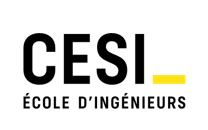

Nous retrouvons notre étudiant et son Smartphone plein à craquer. Il n'a pas renoncé à emmener sa bibliothèque musicale avec lui, mais sa tentative de s'appuyer sur le problème du [sac à dos](https://fr.wikipedia.org/wiki/Probl%C3%A8me_du_sac_%C3%A0_dos) n'a pas été très concluante. L'approche par programmation linéaire n'a pas fonctionné, du fait des variables en nombre entier, qui rendent sa résolution par le Simplexe impossible. C'est dommage, parce que ce problème algorithmique correspond à de nombreux challenges, notamment issus de la logistique.

Question 1 : Parmi les propositions suivantes, lesquelles correspondent à des problèmes réels pouvant être modélisés par le problème du sac à dos ?

1. Optimiser le chargement d'un camion de livraison en maximisant la valeur des colis transportés sans dépasser la capacité de charge
2. Choisir quels articles stocker dans un entrepôt de taille limitée pour maximiser le profit potentiel
3. Sélectionner un portefeuille d'investissements en maximisant le rendement espéré sous contrainte de budget
4. Planifier le chargement de conteneurs maritimes en maximisant la valeur des marchandises embarquées
5. Déterminer le chemin le plus court entre deux villes dans un réseau routier

In [ ]:
Q1 = # A COMPLETER

# 1. Modélisation

Modéliser ce problème sous la forme d'un programme linéaire ?

<em>À COMPLÉTER</em>

# 2. Résolution du problème

Nous allons déjà commencer par mettre en place une approche générique simple pour résoudre ce problème du sac à dos.


## 2.1 Algorithme de Hill Climbing
Question 2 : En quoi consiste l'algorithme Hill Climbing ?

1. On génère aléatoirement plusieurs solutions et on garde la meilleure
2. On part d'une solution initiale, on explore ses voisins à chaque itération en choisissant le meilleur, et on s'arrête quand aucun voisin n'améliore la solution courante
3. On part d'une solution initiale et on accepte parfois des solutions moins bonnes pour s'échapper des optima locaux
4. On divise le problème en sous-problèmes indépendants que l'on résout récursivement

In [ ]:
Q2 = # A COMPLETER

Question 3 : Le Hill Climbing est-il considéré comme une métaheuristique ?

1. Oui, car il exploite une notion de voisinage et peut s'appliquer à tout problème d'optimisation combinatoire
2. Non, car il ne comporte pas d'étape de diversification et se comporte comme un algorithme purement glouton
3. Oui, car il garantit toujours de trouver l'optimum global
4. Non, car il ne s'applique qu'au problème du sac à dos

In [ ]:
Q3 = # A COMPLETER

Question 4 : Quelle est la définition du voisinage retenue pour le problème du sac à dos ?

1. Deux solutions sont voisines si elles ont le même nombre d'objets dans le sac
2. Deux solutions sont voisines si leur valeur totale diffère d'au plus 10 %
3. Deux solutions sont voisines si on peut passer de l'une à l'autre en ajoutant ou en retirant un seul objet
4. Deux solutions sont voisines si elles partagent au moins la moitié de leurs objets

In [ ]:
Q4 = # A COMPLETER

Question 4 : Comment représente-t-on informatiquement une solution du problème du sac à dos ?

1. Un entier représentant le poids total des objets sélectionnés
2. Un mot de n bits, où le i-ème bit indique si le i-ème objet est présent dans le sac
3. Une liste triée des indices des objets sélectionnés par ordre de valeur décroissante
4. Une matrice de n × n booléens représentant les compatibilités entre objets

In [ ]:
Q5 = # A COMPLETER

## 2.2 Structures et fonctions de base


Vous connaissez déjà le principe très général des algorithmes qu'on va implémenter. Il s'agit de générer des solutions valides, d'en évaluer la valeur, et de garder la meilleure. Quelles structures de données Python allons-nous utiliser pour privilégier les performances à l'exécution&nbsp;? Proposez une structure pour&nbsp;:
* une instance du problème
* une solution d'une instance

<em>À COMPLÉTER</em>

### 2.2.1 Génération des instances

Commençons par nous occuper des instances. Si on veut tester nos fonctions, il faut pouvoir générer aléatoirement une instance (étant donnés un poids et une valeur maximale pour tout objet). Pour le nombre d'objets et la capacité du sac, deux entiers feront l'affaire&nbsp;:

In [2]:
nb_objets = 10
capacite = 20

Avec la bibliothèque standard [random](https://docs.python.org/fr/3/library/random.html) de Python, notre fonction de génération d'instance aléatoire sera très simple à écrire. Elle pourra renvoyer un tuple de dictionnaires `(poids, valeur)`, qu'elle aura générés avec des Comprehension. 

In [3]:
import random

def random_objets(poids_max, val_max):
    """
    Cette fonction genere des objets de poids et de valeur
    aleatoires (borne par les valeurs passees en parametre).
    
    Renvoie un tuple de 2 dictionnaires (poids,valeur)
    """

    poids_objets = {i: random.randint(1, poids_max) for i in range(nb_objets)}
    valeur_objets = {i: random.randint(1, val_max) for i in range(nb_objets)}
    
    return poids_objets, valeur_objets

random.seed(a=3) # utiliser un seed explicitement permettra de reproduire les conditions initiales
                 # et de comparer le comportement de différents algorithmes sur une même instance

poids_objets, valeur_objets = random_objets(10, 10)
print(str(poids_objets) + "\n" + str(valeur_objets))

{0: 4, 1: 10, 2: 9, 3: 3, 4: 6, 5: 10, 6: 8, 7: 10, 8: 2, 9: 10}
{0: 1, 1: 8, 2: 5, 3: 9, 4: 4, 5: 4, 6: 8, 7: 9, 8: 9, 9: 8}


### 2.2.2 Représentation d'une solution

On va maintenant écrire une Comprehension qui renvoie les indices des objets présents dans le sac. Pour ça, on va ajouter une [List Comprehension conditionnelle](https://riptutorial.com/python/example/767/conditional-list-comprehensions), qui va [énumérer](https://www.guru99.com/python-enumerate-function.html) le contenu du sac, et filtrer uniquement les valeurs `True`. Essayons déjà d'écrire cette Comprehension.

In [4]:
sac = (True, False, True)

# on teste le générateur avec un List Comprehension
objets =[ i for i, val in enumerate(sac) if val] 

print(objets)

[0, 2]


On obtient bien la liste des indices des objets qui nous intéressent.

Maintenant que nous pouvons générer une instance aléatoire, on va pouvoir implémenter et tester les fonctions de base dont nous aurons besoin. 

- Une fonction pour calculer le poids de la solution : c'est-à-dire la somme des poids des objets dans le sac , pour que la métaheuristique vérifie si une solution est valide (si son poids respecte la capacité du sac). 

- Une fonction calculant la valeur d'une solution, pour que la métaheuristique puisse comparer deux solutions (quelle que soit la métaheuristique envisagée). Le principe est le même que pour la fonction précédente, mais en utilisant la valeur de l'objet plutôt que son poids.

In [5]:
def poids_contenu(sac):
    """
    Cette fonction renvoie la somme des poids des objets dans le sac
    """
    # somme des poids des objets présents dans le sac
    return sum(poids_objets[i] for i, val in enumerate(sac) if val)

def valeur_contenu(sac):
    """
    Cette fonction renvoie la somme des valeurs des objets dans le sac
    """
    # somme des valeurs des objets présents dans le sac
    return sum(valeur_objets[i] for i, val in enumerate(sac) if val)


Tout fonctionne correctement&nbsp;? Pour le vérifier, le plus simple est de générer une solution aléatoire, et de tester nos deux fonctions sur cette solution. 

In [6]:
import random

random.seed(a=3)
nb_objets = 5
poids_objets, valeur_objets = random_objets(10, 10)

sac_test = tuple(random.choice([False, True]) for _ in range(nb_objets))
for o in range(nb_objets):
    print("%d:(%d,%d) "%(o, poids_objets[o], valeur_objets[o]), end='')

print("")
print([i for i, val in enumerate(sac_test) if val]) # affiche les indices des valeurs True de la solution
print("poids=%d, valeur=%d" %(poids_contenu(sac_test), valeur_contenu(sac_test)))

0:(4,10) 1:(10,8) 2:(9,10) 3:(3,2) 4:(6,10) 
[1, 2]
poids=19, valeur=18


Apparemment, ça marche&nbsp;!



# 2 Meta-Heuristique simple
Nous pouvons maintenant nous lancer dans l'implémentation d'un _Hill Climbing_. Pour commencer, il faut implémenter la fonction de calcul de voisinage d'une solution dont on a parlé plus haut. 

## 2.1 Génération de voisinage
Nous voulons donc générer l'ensemble de tous les voisins d'une solution (donc d'un tuple de booléens). Pour être sûr de vous, écrivez cet algorithme de manière plus détaillée. Vous pouvez considérer qu'une fonction de clonage d'une solution est à votre disposition.

<em>À COMPLÉTER</em>

Maintenant, reste à implémenter cet algorithme.




In [7]:
def voisinage(sac):
    """
    Cette fonction est un générateur de tous les voisins valides d'une solution
    """
    for k in range(len(sac)):
        # un indice : on veut les états des k-1 premiers objets et des |sac|-k-1 derniers objets
        # et l'état inverse de l'objet k (attention aux bornes du slicing)
        voisin = sac[:k] + (not(sac[k]), ) + sac[k+1:]
        if (poids_contenu(voisin) <= capacite): 
            yield(voisin)

# on teste
test = (True, False, True)
print (test, "\nvoisins :")
for voisin in voisinage(test):
    print(voisin)

(True, False, True) 
voisins :
(False, False, True)
(True, False, False)


Cela vous parait-il bon&nbsp;? Pourquoi n'y a-t-il pas plus de solutions&nbsp;?

<em>À COMPLÉTER</em>


## 2.2 Hill Climbing


Nous pouvons enfin nous lancer dans l'implémentation de notre heuristique _Hill Climbing_. Si on devait écrire l'algorithme de manière plus détaillée, que pourrait-on proposer&nbsp;?

<em>À COMPLÉTER</em>

Quel défaut a cet algorithme&nbsp;? Comment pourrait-on y remédier&nbsp;?

<em>À COMPLÉTER</em>

Lançons-nous maintenant dans son implémentation&nbsp;!
</blockquote>

In [17]:
def hill_climbing(solution_initiale):
    """
    1. On part d'un élément de notre ensemble de recherche qu'on déclare élément courant
    2. On considere le voisinage de l'élément courant et on choisit le  meilleur d'entre
       eux comme nouvel élément courant
    3. On boucle jusqu'à convergence sur un optimum local
    """

    solution_courante = solution_initiale
    nouveau = True
    nb_iter = 0 # uniquement utilisé pour l'affichage
    
    while (nouveau):
        nb_iter += 1
        meilleure_solution = solution_courante
        # on parcourt tous les voisins de la solution courante pour garder la meilleure
        for voisin in voisinage(solution_courante): 
            if valeur_contenu(voisin) > valeur_contenu(meilleure_solution): 
                meilleure_solution = voisin
                
        nouveau = (meilleure_solution != solution_courante)
        solution_courante = meilleure_solution
    
    return solution_courante

## 2.3 Exécution de l'heuristique
Testons cet algorithme en prenant comme solution initiale un sac vide, et affichons la solution proposée&nbsp;:

In [20]:
random.seed(a=3)
capacite = 20
nb_objets = 100
poids_objets, valeur_objets=random_objets(10, 10)

for o in range(nb_objets):
    print("%d:(%d,%d) \n "%(o, poids_objets[o], valeur_objets[o]), end='')

sac = (False,)*nb_objets # une fonctionnalité utile en Python

print("optimisation locale")
sol = hill_climbing(sac)
print("valeur finale = " + str(valeur_contenu(sol)) + ", capacite=" + str(poids_contenu(sol)) + "/" + str(capacite))
print([i for i, val in enumerate(sol) if val]) # liste des objets dans le sac

0:(4,1) 
 1:(10,5) 
 2:(9,1) 
 3:(3,2) 
 4:(6,2) 
 5:(10,10) 
 6:(8,9) 
 7:(10,1) 
 8:(2,4) 
 9:(10,7) 
 10:(1,5) 
 11:(8,10) 
 12:(5,5) 
 13:(9,3) 
 14:(4,1) 
 15:(4,6) 
 16:(8,6) 
 17:(9,6) 
 18:(9,3) 
 19:(8,7) 
 20:(7,7) 
 21:(3,8) 
 22:(4,9) 
 23:(3,7) 
 24:(9,10) 
 25:(7,9) 
 26:(1,2) 
 27:(2,10) 
 28:(3,9) 
 29:(10,5) 
 30:(1,7) 
 31:(5,4) 
 32:(1,5) 
 33:(5,7) 
 34:(8,5) 
 35:(10,9) 
 36:(7,5) 
 37:(7,9) 
 38:(7,6) 
 39:(10,1) 
 40:(8,7) 
 41:(3,10) 
 42:(6,6) 
 43:(2,1) 
 44:(1,7) 
 45:(3,10) 
 46:(8,10) 
 47:(4,3) 
 48:(5,1) 
 49:(7,6) 
 50:(5,8) 
 51:(7,6) 
 52:(9,6) 
 53:(7,10) 
 54:(10,5) 
 55:(6,8) 
 56:(9,1) 
 57:(10,10) 
 58:(7,1) 
 59:(10,1) 
 60:(4,6) 
 61:(6,5) 
 62:(1,8) 
 63:(5,5) 
 64:(10,10) 
 65:(3,10) 
 66:(6,6) 
 67:(9,3) 
 68:(10,6) 
 69:(10,3) 
 70:(2,6) 
 71:(4,6) 
 72:(10,10) 
 73:(5,5) 
 74:(5,5) 
 75:(2,7) 
 76:(2,2) 
 77:(8,1) 
 78:(8,10) 
 79:(2,3) 
 80:(6,5) 
 81:(2,9) 
 82:(7,4) 
 83:(3,5) 
 84:(1,4) 
 85:(5,6) 
 86:(7,3) 
 87:(7,7) 
 88:(2,2) 
 89:(

Dix objets, ce n'est pas beaucoup&nbsp;!! Ceci dit, on peut peut-être faire quelque chose pour améliorer ça. Réfléchissez&nbsp;: cet algorithme est [déterministe](https://fr.wikipedia.org/wiki/Algorithme_d%C3%A9terministe). Lorsqu'on considère un algorithme d'optimisation comme la recherche tabou, qu'est-ce que ça implique en termes de qualité de solution pour une instance donnée&nbsp;?

<em>À COMPLÉTER</em>

Ça ne vous donne pas une idée pour améliorer le résultat produit par l'algorithme&nbsp;? Comment pourrait-on implémenter une telle approche&nbsp;?

<em>À COMPLÉTER</em>

C'est simple à mettre en place, surtout en Python. Quelle fonction devez-vous implémenter&nbsp;? Que fera-t-elle exactement&nbsp;? Un indice, les fonctions de génération aléatoire de Python, par exemple [<code class="cm-s-ipython language-python"><span class="cm-builtin">random_choice</span></code></a>](https://docs.python.org/3/library/random.html#random.choice) devraient vous être utiles.

<em>À COMPLÉTER</em>

Allons-y&nbsp;!



In [21]:
def random_solution():
    sac = tuple(random.choice([False, True]) for _ in range(nb_objets))

    while (poids_contenu(sac) > capacite):
        # liste des indices de valeur `True` dans le sac
        objets_presents = tuple(i for i, val in enumerate(sac) if val)
        
        # choix aléatoire d'un objet à supprimer parmi ceux présents dans le sac
        objet_supprime = random.choice(objets_presents)
        
        # suppression de l'objet sélectionné aléatoirement
        sac = sac[:objet_supprime] + (False,) + sac[objet_supprime+1:]

    return sac

Il ne nous reste plus qu'à tester tout ça. Pour commencer, essayons avec 10 itérations. À chaque itération, affichez le résultat de la recherche (comme l'affichage final l.14 du code à compléter, mais sans afficher le détail de la solution), qu'on puisse voir un peu ce qui se passe.

In [23]:
val_max = 0
for i in range(5):
    sac = random_solution()
    solution = hill_climbing(sac)
    print(f"Iteration {i} : {valeur_contenu(solution)}" )
    if val_max < valeur_contenu(solution):
        sol_max = solution 
        val_max = valeur_contenu(solution)

print("\nvaleur finale = %d, capacite=%d/%d\n" % (val_max, poids_contenu(sol_max),capacite))
print([i for i, val in enumerate(sol_max) if val])


Iteration 0 : 8
Iteration 1 : 39
Iteration 2 : 30
Iteration 3 : 41
Iteration 4 : 18

valeur finale = 41, capacite=20/20

[27, 38, 41, 66, 81]


On a nettement amélioré le résultat&nbsp;! Et on constate effectivement que l'optimum local trouvé dépend de la solution de départ. En testant plusieurs solutions initiales, on améliore dans certains cas la solution trouvée. Comment s'appelle cette technique&nbsp;?

<em>À COMPLÉTER</em>

<em>À COMPLÉTER</em>


# 3 Méta-heuristiques
Finalement, on a déjà implémenté une première méta-heuristique, mais on ne va pas s'arrêter là&nbsp;!

## 3.1 Recherche avec liste tabou
Une métaheuristique un peu plus maligne qu'un Hill Climbing devrait donner de meilleurs résultats. Parmi toutes les métaheuristiques de la littérature, la méthode par [recherche avec liste tabou](https://fr.wikipedia.org/wiki/Recherche_tabou) (qu'on appelle souvent _méthode tabou_ par raccourcis) est celle qui pourrait être adaptée le plus facilement en partant du code du Hill Climbing. Pourquoi&nbsp;?

<em>À COMPLÉTER</em>

De quelle structure de données algorithmique avons-nous besoin pour gérer ça&nbsp;?

<em>À COMPLÉTER</em>

Pour implémenter ça en Python, quelle structure vous semble adaptée du point de vue des performances&nbsp;?

<em>À COMPLÉTER</em>

Cette fois, on a tout ce qu'il nous faut. Lançons-nous donc dans cette implémentation&nbsp;:

In [25]:
from collections import deque

def recherche_tabou(solution_initiale, taille_tabou, iter_max):
    """
    1. On part d'un élément de notre ensemble de recherche qu'on déclare élément courant
    2. On considère le voisinage de l'élément courant, on choisit le meilleur d'entre
       eux comme nouvel élément courant, parmi ceux absents de la liste tabou, et on l'ajoute
       à la liste tabou
    3. On boucle jusqu'à condition de sortie.
    """
    nb_iter = 0
    liste_tabou = deque((), maxlen= taille_tabou)

    # variables solutions pour la recherche du voisin optimal non tabou
    solution_courante = solution_initiale
    meilleure = solution_initiale
    meilleure_globale = solution_initiale

    # variables valeurs pour la recherche du voisin optimal non tabou
    valeur_meilleure = valeur_contenu(solution_initiale)
    valeur_meilleure_globale = valeur_meilleure

    
    while (nb_iter < iter_max):
        valeur_meilleure = -1
        
        # on parcourt tous les voisins de la solution courante
        for voisin in voisinage(solution_courante):
            valeur_voisin = valeur_contenu(voisin)

            if valeur_voisin > valeur_meilleure and voisin not in liste_tabou: 
                valeur_meilleure = valeur_voisin 
                meilleure = voisin

        # on met à jour la meilleure solution rencontrée depuis le debut
        if valeur_meilleure > valeur_meilleure_globale:
            meilleure_globale = meilleure
            valeur_meilleure_globale = valeur_meilleure
            nb_iter = 0
        else:
            nb_iter += 1

        # on passe au meilleur voisin non tabou trouvé
        solution_courante = meilleure

        # on met à jour la liste tabou
        liste_tabou.append(solution_courante)

    return meilleure_globale

Un test avec une liste tabou de taille 5 sur la même instance que précédemment va nous permettre de comparer le résultat avec celui obtenu par optimisation locale&nbsp;:

In [26]:
nb_objets = 100
capacite = 20
random.seed(a=3)
poids_objets, valeur_objets = random_objets(10, 10)
sac = (False,)*nb_objets
taille_tabou=5
iter_max=30

print("tabou de taille 5")
sol=recherche_tabou(sac, taille_tabou, iter_max)
print("valeur finale = " + str(valeur_contenu(sol)) + ", capacite="+str(poids_contenu(sol)) + "/" + str(capacite))

tabou de taille 5
valeur finale = 62, capacite=20/20


On a nettement amélioré la qualité par rapport à la solution obtenue simplement par optimisation locale&nbsp;! C'est dire si cette première approche était inefficace… On est même meilleurs qu'avec le multi-start&nbsp;!

## 3.2 Tabou avec multi-start

D'ailleurs, on peut réutiliser ce principe du multi-start. Implémentez-le en renforçant la diversification (500 itérations, par exemple)&nbsp;:

In [27]:
random.seed(a=3)

val_max = 0
for i in range(5):
    sac = random_solution()
    solution = recherche_tabou(sac, taille_tabou=5, iter_max=500)
    print(f"Iteration {i} : {valeur_contenu(solution)}" )
    if val_max < valeur_contenu(solution):
        sol_max = solution 
        val_max = valeur_contenu(solution)

print("\nvaleur finale = %d, capacite=%d/%d\n" % (val_max, poids_contenu(sol_max),capacite))
print([i for i, val in enumerate(sol_max) if val])

Iteration 0 : 64
Iteration 1 : 60
Iteration 2 : 55
Iteration 3 : 64
Iteration 4 : 54

valeur finale = 64, capacite=20/20

[11, 27, 41, 44, 45, 62, 81]


La solution s'en trouve encore améliorée. Ceci dit, le surcoût en temps de calcul est conséquent.


Or, il y a un moyen d'accélérer les calculs sans toucher à grand chose. Certaines des fonctions qu'on a implémentées sont _pures_. Et ça, ça va nous permettre de mettre en place une accélération de l'exécution du code. Avez-vous une idée de comment faire&nbsp;?

<em>À COMPLÉTER</em>

D'ailleurs, heureusement qu'on a choisi un tuple pour représenter une solution, car on n'aurait pas pu mettre en place cette technique avec des listes (qui ne sont pas hachables).

Avant tout, relançons le calcul en comptant le temps CPU, pour avoir une idée du gain qu'on obtiendra ensuite.



In [14]:
import time
random.seed(a=3)

sol_max = None
val_max = 0

start = time.process_time()

# multi-start de 500 itérations
#À COMPLÉTER

stop = time.process_time()

print("valeur finale = " + str(valeur_contenu(sol_max)))
print("calculé en ", stop-start, 's')

Testons maintenant cette technique, en redéfinissant les fonctions concernées.

In [28]:
from functools import lru_cache

@lru_cache(maxsize=None)
def voisinage(sac):
    """
    Cette fonction est un générateur de tous les voisins valides d'une solution
    """
    for k in range(len(sac)):
        # un indice : on veut les états des k-1 premiers objets et des |sac|-k-1 derniers objets
        # et l'état inverse de l'objet k (attention aux bornes du slicing)
        voisin = sac[:k] + (not(sac[k]), ) + sac[k+1:]
        if (poids_contenu(voisin) <= capacite): 
            yield(voisin)

@lru_cache(maxsize=None)
def poids_contenu(sac):
    """
    Cette fonction renvoie la somme des poids des objets dans le sac
    """
    # somme des poids des objets présents dans le sac
    return sum(poids_objets[i] for i, val in enumerate(sac) if val)
@lru_cache(maxsize=None)
def valeur_contenu(sac):
    """
    Cette fonction renvoie la somme des valeurs des objets dans le sac
    """
    # somme des valeurs des objets présents dans le sac
    return sum(valeur_objets[i] for i, val in enumerate(sac) if val)

Et testons ça en relançant le calcul précédent&nbsp;:

In [16]:
random.seed(a=3)

sol_max = None
val_max = -1

start = time.process_time()

val_max = 0
for i in range(500):
    sac = random_solution()
    solution = recherche_tabou(sac, taille_tabou=5, iter_max=500)
    print(f"Iteration {i} : {valeur_contenu(solution)}" )
    if val_max < valeur_contenu(solution):
        sol_max = solution 
        val_max = valeur_contenu(solution)

print("\nvaleur finale = %d, capacite=%d/%d\n" % (val_max, poids_contenu(sol_max),capacite))
print([i for i, val in enumerate(sol_max) if val])

stop = time.process_time()

print("valeur finale = " + str(valeur_contenu(sol_max)))
print("calculé en ", stop-start, 's')

L'accélération est impressionnante, le temps de calcul a été quasiment divisé par 4&nbsp;! Et plus on fera de calculs sur cette instance, plus on accélérera (en échange d'une consommation mémoire plus importante). Pour vous en convaincre, il suffit de relancer le même calcul, mais avec un seed différent&nbsp;:

In [17]:
#### Copiez-collez le code de la cellule précédente
random.seed(a=5)

sol_max = None
val_max = 0

start = time.process_time()
# multi-start de 500 itérations
#À COMPLÉTER

stop = time.process_time()

print("valeur finale = " + str(valeur_contenu(sol_max)))
print("calculé en ", stop-start, 's')

Là aussi, on est allés plus vite, alors que le scénario d'exécution n'est pas le même, ce qui signifie que les solutions initiales considérées sont différentes.


Et si vous vous demandez pourquoi on obtient malgré tout la même valeur de solution, on aura la réponse au prochain Workshop&nbsp;!

# 4. Conclusion

Ce Workshop est maintenant terminé, et on a enfin réussi à faire quelque chose de ce problème de sac à dos, puisque vous avez implémenté, non pas une, mais trois métaheuristiques, un Hill-Climbing avec multi-start, une recherche tabou simple, et une avec multi-start.


Même si vous partez sur une implémentation différente pour votre projet, vous voyez que ce n'est pas si compliqué. Prenons le cas d'un algorithme génétique. Dans le cas d'un sac à dos, que représenterait un gène&nbsp;?

<em>À COMPLÉTER</em>

Si on devait l'implémenter, on aurait déjà pas mal de fonctions réutilisables (génération aléatoire de solution, évaluation de la faisabilité d'une solution, de sa valeur). Il faudrait juste implémenter une fonction de croisement et une de mutation. Quel genre de croisement pourrait être envisagé&nbsp;?

<em>À COMPLÉTER</em>

Et pour la mutation&nbsp;?

<em>À COMPLÉTER</em>

Une fois ces fonctions supplémentaires implémentées, le corps de l'algorithme ne sera pas tellement plus compliqué que celui de l'algorithme tabou qu'on vient d'écrire.


Mais la question qui se pose, c'est&nbsp;: est-ce que les solutions qu'on construit sont de bonne qualité&nbsp;? Finalement, on n'en sait rien. 

Il va bien falloir analyser le comportement de l'algorithme en fonction de certains paramètres, pour pouvoir déterminer s'il est efficace ou pas, et si nécessaire optimiser son fonctionnement. Et ça, c'est l'objet du prochain Workshop&nbsp;!